In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score,
    roc_auc_score, RocCurveDisplay, average_precision_score, PrecisionRecallDisplay
)
from lightgbm import LGBMClassifier

In [16]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/_0eYOqji3unP1tDNKWZMjg/weatherAUS-2.csv"
df = pd.read_csv(URL)
pd.set_option("display.max_columns",None)
#this prevents panda from hiding the columns with ............

In [17]:
df.head(10)


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
5,2008-12-06,Albury,14.6,29.7,0.2,NaN,NaN,WNW,56.0,W,W,19.0,24.0,55.0,23.0,1009.2,1005.4,NaN,NaN,20.6,28.9,No,No
6,2008-12-07,Albury,14.3,25.0,0.0,NaN,NaN,W,50.0,SW,W,20.0,24.0,49.0,19.0,1009.6,1008.2,1.0,NaN,18.1,24.6,No,No
7,2008-12-08,Albury,7.7,26.7,0.0,NaN,NaN,W,35.0,SSE,W,6.0,17.0,48.0,19.0,1013.4,1010.1,NaN,NaN,16.3,25.5,No,No
8,2008-12-09,Albury,9.7,31.9,0.0,NaN,NaN,NNW,80.0,SE,NW,7.0,28.0,42.0,9.0,1008.9,1003.6,NaN,NaN,18.3,30.2,No,Yes
9,2008-12-10,Albury,13.1,30.1,1.4,NaN,NaN,W,28.0,S,SSE,15.0,11.0,58.0,27.0,1007.0,1005.7,NaN,NaN,20.1,28.2,Yes,No


In [18]:
print("RAW SHAPE:",df.shape)
print("DATE RANGE:",df["Date"].min(),"->",df["Date"].max())
print("LOCATIONS:",df["Location"].nunique())

RAW SHAPE: (145460, 23)
DATE RANGE: 2007-11-01 -> 2017-06-25
LOCATIONS: 49


In [19]:
#finding the missing value percentage of each column
missing_percentage=(df.isna().mean()*100).sort_values(ascending=False)
print("missing percentages by column are:")
print(missing_percentage.round(1))

missing percentages by column are:
Sunshine         48.0
Evaporation      43.2
Cloud3pm         40.8
Cloud9am         38.4
Pressure9am      10.4
Pressure3pm      10.3
WindDir9am        7.3
WindGustDir       7.1
WindGustSpeed     7.1
Humidity3pm       3.1
WindDir3pm        2.9
Temp3pm           2.5
RainTomorrow      2.2
Rainfall          2.2
RainToday         2.2
WindSpeed3pm      2.1
Humidity9am       1.8
WindSpeed9am      1.2
Temp9am           1.2
MinTemp           1.0
MaxTemp           0.9
Date              0.0
Location          0.0
dtype: float64


In [20]:
heavy_missing_threshold=40
heavy_missing_columns=missing_percentage[missing_percentage>40].index.tolist()
print(f"Columns above {heavy_missing_threshold}% missing: {heavy_missing_columns}")


Columns above 40% missing: ['Sunshine', 'Evaporation', 'Cloud3pm']


In [21]:
#dropping the columns that are 40%missing
DROP_COLS = ["Sunshine", "Evaporation", "Cloud9am", "Cloud3pm"]
df = df.drop(columns=DROP_COLS)

In [22]:
#making seasons column
df["Date"] = pd.to_datetime(df["Date"])
df["Season"] = df["Date"].dt.month % 12 // 3 + 1
#finding the numerical columns
numeric_columns=df.select_dtypes(include=["float64","int64"]).columns.tolist()
categorical_columns=[c for c in df.select_dtypes(include=["object"]).columns if c!="Date"]
#date is excluded on purpose.we dont want to treat date as a category
#filling the missing values in categorical and numerical columns
for col in numeric_columns:
    df[col] = df.groupby(["Location", "Season"])[col].transform(lambda s: s.fillna(s.median()))
    df[col] = df[col].fillna(df[col].median())
for col in categorical_columns:
    df[col] = df[col].fillna("Missing")

print(f"Shape after filling gaps: {df.shape}")




Shape after filling gaps: (145460, 20)


In [23]:
#building X(FEATURES)AND y(TARGET)
y=(df["RainTomorrow"]=="Yes").astype(int)#1=rained 0=didnt
x = df.drop(columns=["RainTomorrow", "Date"])
#turning the text categories  into 0/1 columns
x=pd.get_dummies(x,columns=x.select_dtypes(include="object").columns,drop_first=True)
print(f"Final Feature count:{x.shape[1]}")

Final Feature count:111


In [24]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.fit_transform(x_test)

====LOGISTIC REGRESSION======
Best C: {'C': 10}
              precision    recall  f1-score   support

           0       0.92      0.79      0.85     22717
           1       0.51      0.77      0.61      6375

    accuracy                           0.79     29092
   macro avg       0.72      0.78      0.73     29092
weighted avg       0.83      0.79      0.80     29092

ROC-AUC: 0.8625
PR-AUC (average precision): 0.6867


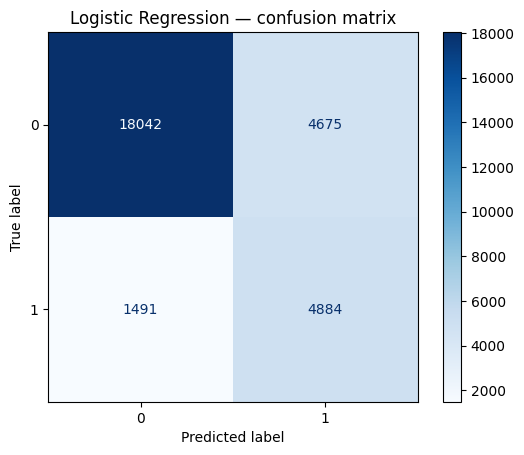

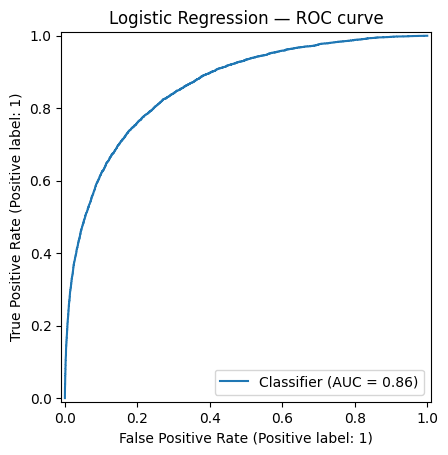

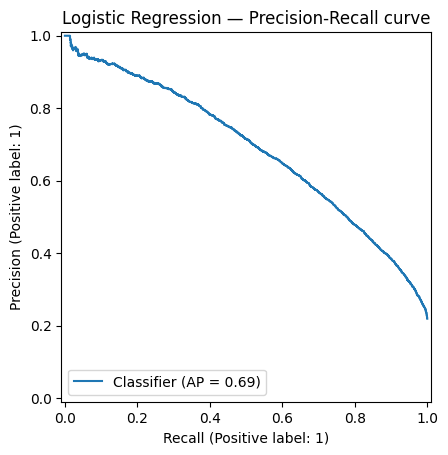

In [29]:
#now using logistic regression
print("=============================")
print("====LOGISTIC REGRESSION======")
print("=============================")
logreg=LogisticRegression(max_iter=1000,class_weight="balanced")
logreg_grid=GridSearchCV(logreg,param_grid={"C":[0.01,0.1,1,10]},cv=5,scoring="f1")
logreg_grid.fit(x_train_scaled,y_train)
logreg_best=logreg_grid.best_estimator_
logreg_pred = logreg_best.predict(x_test_scaled)
logreg_proba = logreg_best.predict_proba(x_test_scaled)[:, 1]   # probability of "rain"
print("Best C:", logreg_grid.best_params_)
print(classification_report(y_test, logreg_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, logreg_proba):.4f}")
print(f"PR-AUC (average precision): {average_precision_score(y_test, logreg_proba):.4f}")

ConfusionMatrixDisplay(confusion_matrix(y_test, logreg_pred)).plot(cmap="Blues")
plt.title("Logistic Regression — confusion matrix")
plt.savefig("logreg_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

RocCurveDisplay.from_predictions(y_test, logreg_proba)
plt.title("Logistic Regression — ROC curve")
plt.savefig("logreg_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, logreg_proba)
plt.title("Logistic Regression — Precision-Recall curve")
plt.savefig("logreg_pr_curve.png", dpi=150, bbox_inches="tight")
plt.show()

=====RANDOM FORSET=============
Starting GridSearchCV...
(116368, 111)


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


GridSearchCV finished!
Best params: {'max_depth': 20, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       0.90      0.90      0.90     22717
           1       0.65      0.63      0.64      6375

    accuracy                           0.84     29092
   macro avg       0.77      0.77      0.77     29092
weighted avg       0.84      0.84      0.84     29092

ROC-AUC: 0.8753
PR-AUC (average precision): 0.7108


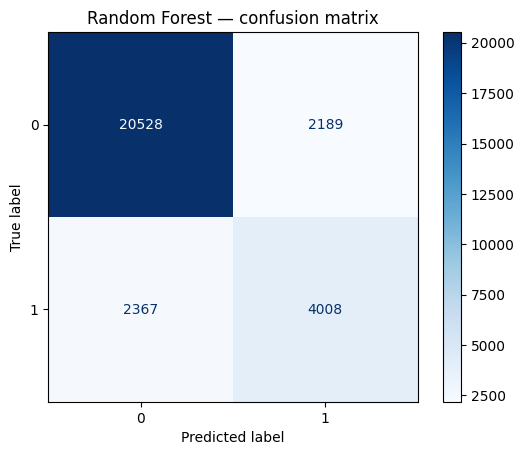

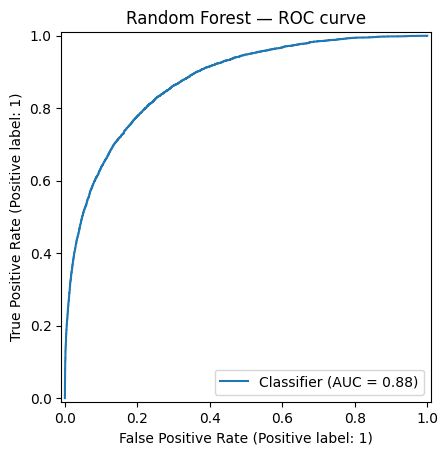

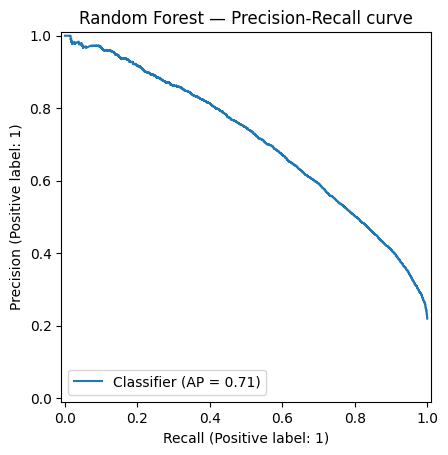

In [34]:
print("===============================")
print("=====RANDOM FORSET=============")
print("===============================")
rf = RandomForestClassifier(class_weight="balanced", random_state=42,n_jobs=-1)
rf_grid = GridSearchCV(
    rf,
    param_grid={"n_estimators": [100, 200], "max_depth": [None, 10, 20]},
    cv=3,
    scoring="f1",
    n_jobs=-1
)
print("Starting GridSearchCV...")
print(x_train_scaled.shape)
rf_grid.fit(x_train_scaled, y_train)
print("GridSearchCV finished!")
rf_best = rf_grid.best_estimator_

rf_pred = rf_best.predict(x_test_scaled)
rf_proba = rf_best.predict_proba(x_test_scaled)[:, 1]

print("Best params:", rf_grid.best_params_)
print(classification_report(y_test, rf_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_proba):.4f}")
print(f"PR-AUC (average precision): {average_precision_score(y_test, rf_proba):.4f}")

ConfusionMatrixDisplay(confusion_matrix(y_test, rf_pred)).plot(cmap="Blues")
plt.title("Random Forest — confusion matrix")
plt.savefig("rf_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

RocCurveDisplay.from_predictions(y_test, rf_proba)
plt.title("Random Forest — ROC curve")
plt.savefig("rf_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, rf_proba)
plt.title("Random Forest — Precision-Recall curve")
plt.savefig("rf_pr_curve.png", dpi=150, bbox_inches="tight")
plt.show()

=====LGBM CLASSIFIER===========
Fitting 3 folds for each of 4 candidates, totalling 12 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Best params: {'n_estimators': 200, 'num_leaves': 63}
              precision    recall  f1-score   support

           0       0.93      0.82      0.87     22717
           1       0.55      0.78      0.64      6375

    accuracy                           0.81     29092
   macro avg       0.74      0.80      0.76     29092
weighted avg       0.85      0.81      0.82     29092

ROC-AUC: 0.8878
PR-AUC (average precision): 0.7372


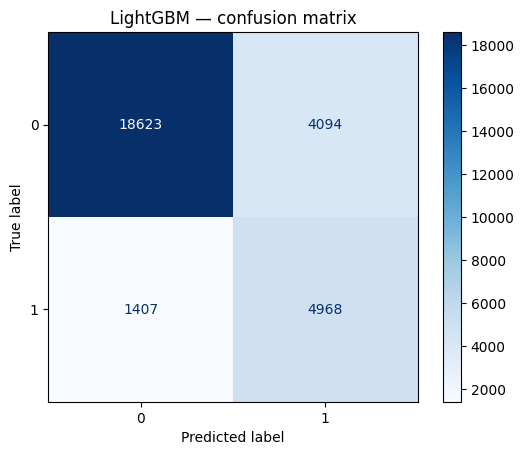

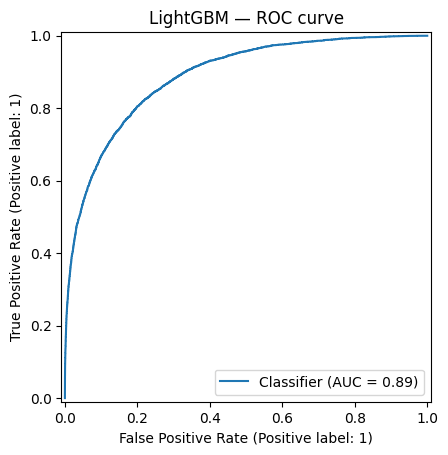

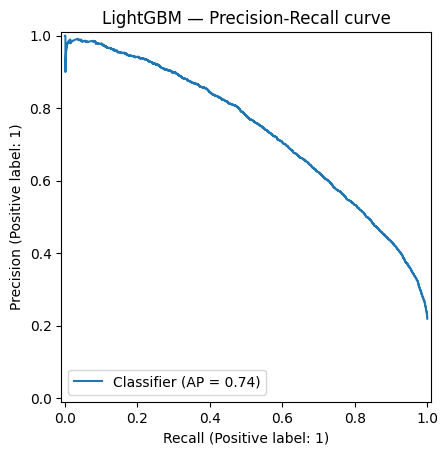

In [35]:
print("===============================")
print("=====LGBM CLASSIFIER===========")
print("===============================")
lgbm = LGBMClassifier(class_weight="balanced", random_state=42,n_jobs=-1, verbose=-1)
lgbm_grid = GridSearchCV(
    lgbm,
    param_grid={"n_estimators": [100, 200], "num_leaves": [31, 63]},
    cv=3,
    scoring="f1",
    n_jobs=-1,
    verbose=2
)
lgbm_grid.fit(x_train_scaled, y_train)
lgbm_best = lgbm_grid.best_estimator_

lgbm_pred = lgbm_best.predict(x_test_scaled)
lgbm_proba = lgbm_best.predict_proba(x_test_scaled)[:, 1]

print("Best params:", lgbm_grid.best_params_)
print(classification_report(y_test, lgbm_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, lgbm_proba):.4f}")
print(f"PR-AUC (average precision): {average_precision_score(y_test, lgbm_proba):.4f}")

ConfusionMatrixDisplay(confusion_matrix(y_test, lgbm_pred)).plot(cmap="Blues")
plt.title("LightGBM — confusion matrix")
plt.savefig("lgbm_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

RocCurveDisplay.from_predictions(y_test, lgbm_proba)
plt.title("LightGBM — ROC curve")
plt.savefig("lgbm_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, lgbm_proba)
plt.title("LightGBM — Precision-Recall curve")
plt.savefig("lgbm_pr_curve.png", dpi=150, bbox_inches="tight")
plt.show()


**NOW WE ARE GONNA COMPARE THE RESULT OF ALL THREE CLASSIFIERS **


=== Final comparison ===
Logistic Regression: F1=0.6130  ROC-AUC=0.8625  PR-AUC=0.6867
Random Forest: F1=0.6376  ROC-AUC=0.8753  PR-AUC=0.7108
LightGBM: F1=0.6436  ROC-AUC=0.8878  PR-AUC=0.7372


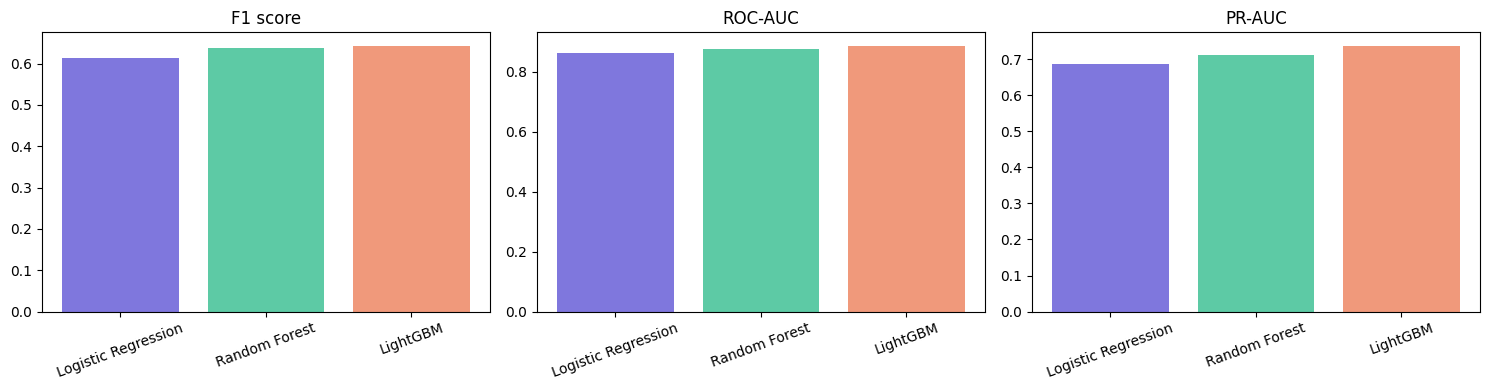


Done.


In [37]:
model_names = ["Logistic Regression", "Random Forest", "LightGBM"]
f1_scores = [
    f1_score(y_test, logreg_pred),
    f1_score(y_test, rf_pred),
    f1_score(y_test, lgbm_pred),
]
roc_auc_scores = [
    roc_auc_score(y_test, logreg_proba),
    roc_auc_score(y_test, rf_proba),
    roc_auc_score(y_test, lgbm_proba),
]
pr_auc_scores = [
    average_precision_score(y_test, logreg_proba),
    average_precision_score(y_test, rf_proba),
    average_precision_score(y_test, lgbm_proba),
]

print("\n=== Final comparison ===")
for name, f1, roc, pr in zip(model_names, f1_scores, roc_auc_scores, pr_auc_scores):
    print(f"{name}: F1={f1:.4f}  ROC-AUC={roc:.4f}  PR-AUC={pr:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].bar(model_names, f1_scores, color=["#7F77DD", "#5DCAA5", "#F0997B"])
axes[0].set_title("F1 score")
axes[1].bar(model_names, roc_auc_scores, color=["#7F77DD", "#5DCAA5", "#F0997B"])
axes[1].set_title("ROC-AUC")
axes[2].bar(model_names, pr_auc_scores, color=["#7F77DD", "#5DCAA5", "#F0997B"])
axes[2].set_title("PR-AUC")
for ax in axes:
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nDone.")

Among the three models, LightGBM achieved the best overall performance, obtaining the highest F1-score, ROC-AUC, and Precision-Recall AUC. These results indicate that LightGBM was the most effective model for predicting rainfall on this dataset.